By the end of Day 5, we will:

1.   Understand whether your AI learned correctly.
2.   Learn what Precision, Recall, mAP, and Confidence mean.
3.   Use the trained model (best.pt) to detect potholes in new images
4.   Save the prediction results.
5.   Organize outputs and update GitHub.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 888.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.8 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
# Load Your Trained Model
model = YOLO(
    "/content/drive/My Drive/RoadShield-AI/models/yolov8_pothole-2/weights/best.pt"
)

In [5]:
results = model.predict(
    source="/content/drive/My Drive/RoadShield-AI/assets/test_images",
    conf=0.15,
    save=True
)


image 1/7 /content/drive/My Drive/RoadShield-AI/assets/test_images/021_png.rf.62018af40395c6e9c3521ab19130fd12.jpg: 352x640 7 potholes, 243.5ms
image 2/7 /content/drive/My Drive/RoadShield-AI/assets/test_images/083_png.rf.ad7a6bc6ef86a34380ce09127ab14924.jpg: 352x640 11 potholes, 115.1ms
image 3/7 /content/drive/My Drive/RoadShield-AI/assets/test_images/road.jpg: 448x640 1 pothole, 235.7ms
image 4/7 /content/drive/My Drive/RoadShield-AI/assets/test_images/road1.jpg: 640x384 2 potholes, 122.7ms
image 5/7 /content/drive/My Drive/RoadShield-AI/assets/test_images/road1012.jpg: 640x640 2 potholes, 212.6ms
image 6/7 /content/drive/My Drive/RoadShield-AI/assets/test_images/road1020.jpg: 480x640 6 potholes, 154.9ms
image 7/7 /content/drive/My Drive/RoadShield-AI/assets/test_images/road1111.jpg: 480x640 5 potholes, 217.7ms
Speed: 5.1ms preprocess, 186.0ms inference, 5.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


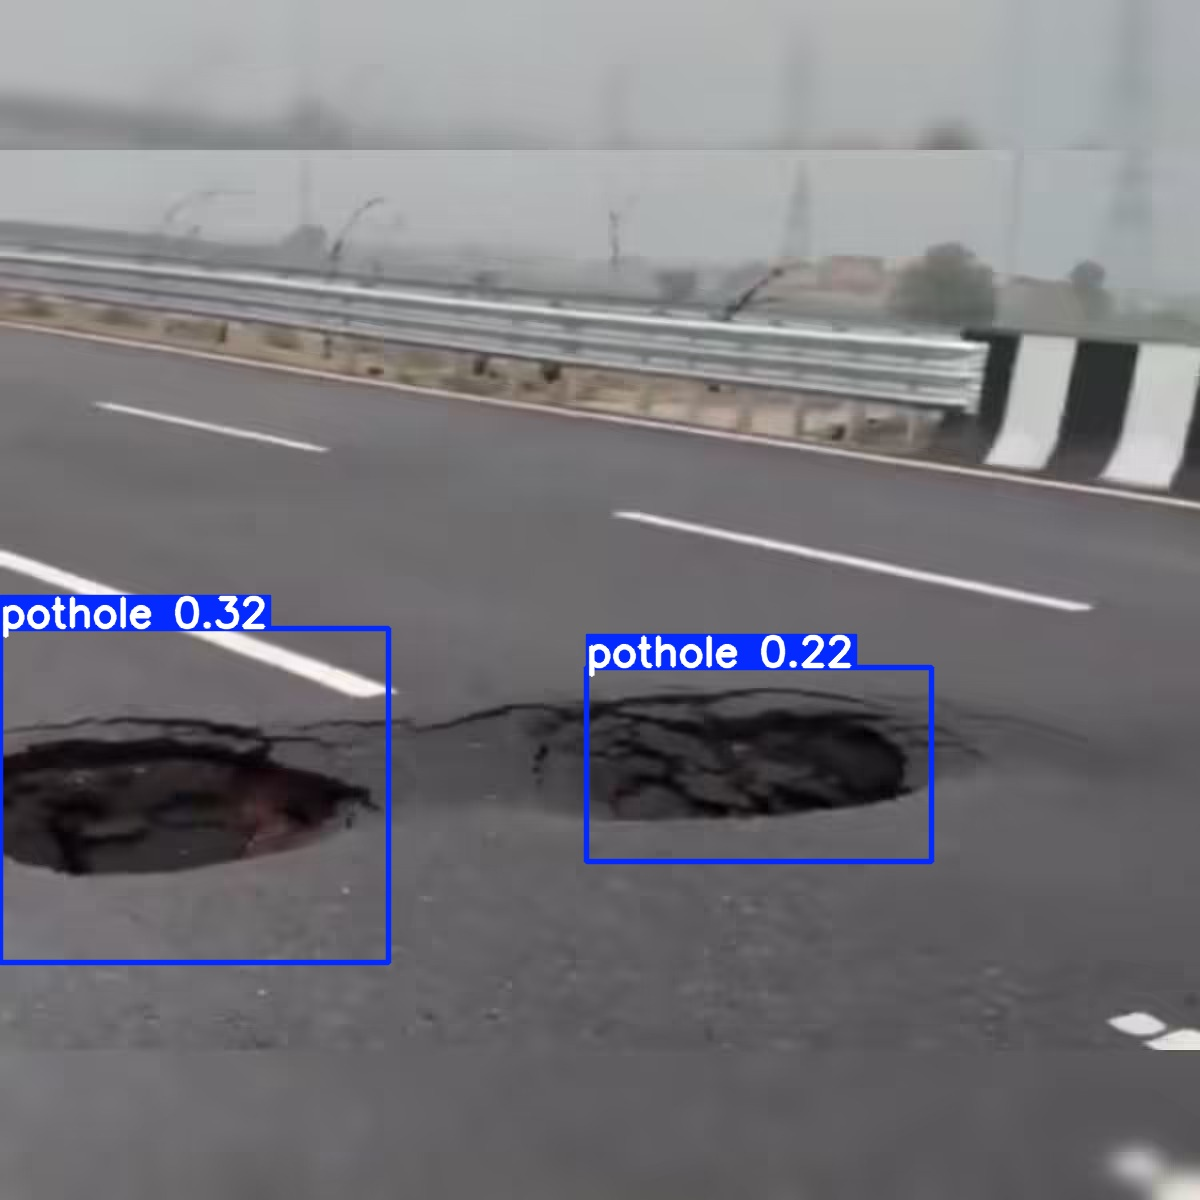

In [6]:
from IPython.display import Image

Image(filename="runs/detect/predict/road1012.jpg")

In [7]:
results_df = pd.read_csv(
    "/content/drive/My Drive/RoadShield-AI/models/yolov8_pothole-2/results.csv"
)

results_df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,85.426,1.89700,2.26070,1.65180,0.48759,0.30607,0.30055,0.09857,2.15537,2.69174,1.82841,0.000663,0.000663,0.000663
1,2,148.216,1.73632,1.74709,1.53007,0.60280,0.55052,0.55401,0.19377,2.23397,1.80589,1.79962,0.001001,0.001001,0.001001
2,3,211.183,1.66697,1.60079,1.50019,0.72183,0.66082,0.70136,0.29710,1.92347,1.55280,1.57260,0.001008,0.001008,0.001008
3,4,273.677,1.59341,1.40438,1.43843,0.74007,0.69859,0.76101,0.32534,1.92863,1.45585,1.53485,0.000515,0.000515,0.000515
